In [437]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

In [438]:
xplot = np.linspace(0, 28, 560)
yplot = np.linspace(0, 20, 400)

X, Y = np.meshgrid(xplot, yplot, indexing='xy')

In [439]:

def potencial(X,Y):
    condenserXSize = 18
    condenserYSize = 14

    centerX = (np.min(X)+np.max(X))/2
    centerY = (np.min(Y)+np.max(Y))/2

    A = -1.427
    B = +  24.259


    return np.where(X > centerX + condenserXSize/2,
                    0,
                    np.where(X < centerX -condenserXSize/2,
                              0,
                              np.where(Y > centerY + condenserYSize/2,
                                       0,
                                       np.where(Y < centerY -condenserYSize/2,
                                                 0,
                                                 A*Y + B)

                              )
                        )
                    )


    '''if (dist(x,y,7,10) < 0.1):
        return 0
    else:
        if (dist(x,y,21,10) < 0.1):
            return 19
        else:
            return -10/(dist(x,y,7,10)+0.5) + 10/(dist(x,y,21,10)+0.5)'''


In [440]:
print(potencial(10,5.1))

16.9813


In [441]:
data = potencial(X,Y)

In [442]:
realSpacingInXplotSpace = 29/xplot.size
realSpacingInYplotSpace = 21/yplot.size

fieldGradient = -np.array(np.gradient(data, realSpacingInYplotSpace, realSpacingInXplotSpace)) #unidades de voltio / cm

condenserXSize = 18
condenserYSize = 14

centerX = (np.min(X)+np.max(X))/2
centerY = (np.min(Y)+np.max(Y))/2

'''fieldGradient = np.where(X > centerX + condenserXSize/2 -0.2,
                    0,
                    np.where(X < centerX -condenserXSize/2 + 0.2,
                              0,
                              np.where(Y > centerY + condenserYSize/2 - 0.01,
                                       0,
                                       np.where(Y < centerY -condenserYSize/2 + 0.1,
                                                 0,
                                                fieldGradient))))'''

fieldGradient = np.where(np.abs(fieldGradient[0,:]**2+fieldGradient[1,:]**2) < 0.01,
                         0,
                         (fieldGradient[:,200,300][:,None,None])
                         )

In [443]:
normMatrix = np.sqrt(fieldGradient[0]**2 + fieldGradient[1]**2)
normalizedFieldGradientU = fieldGradient[0]/normMatrix
normalizedFieldGradientV = fieldGradient[1]/normMatrix

C:\Users\Alex\AppData\Local\Temp\ipykernel_6020\960727431.py:2: RuntimeWarning: invalid value encountered in divide
  normalizedFieldGradientU = fieldGradient[0]/normMatrix
C:\Users\Alex\AppData\Local\Temp\ipykernel_6020\960727431.py:3: RuntimeWarning: invalid value encountered in divide
  normalizedFieldGradientV = fieldGradient[1]/normMatrix


In [444]:
colors = ["#03071e","#370617","#6a040f","#9d0208","#d00000","#dc2f02","#e85d04","#f48c06","#faa307"]
red_orange_cmap = mpl.colors.LinearSegmentedColormap.from_list("red_orange", colors)

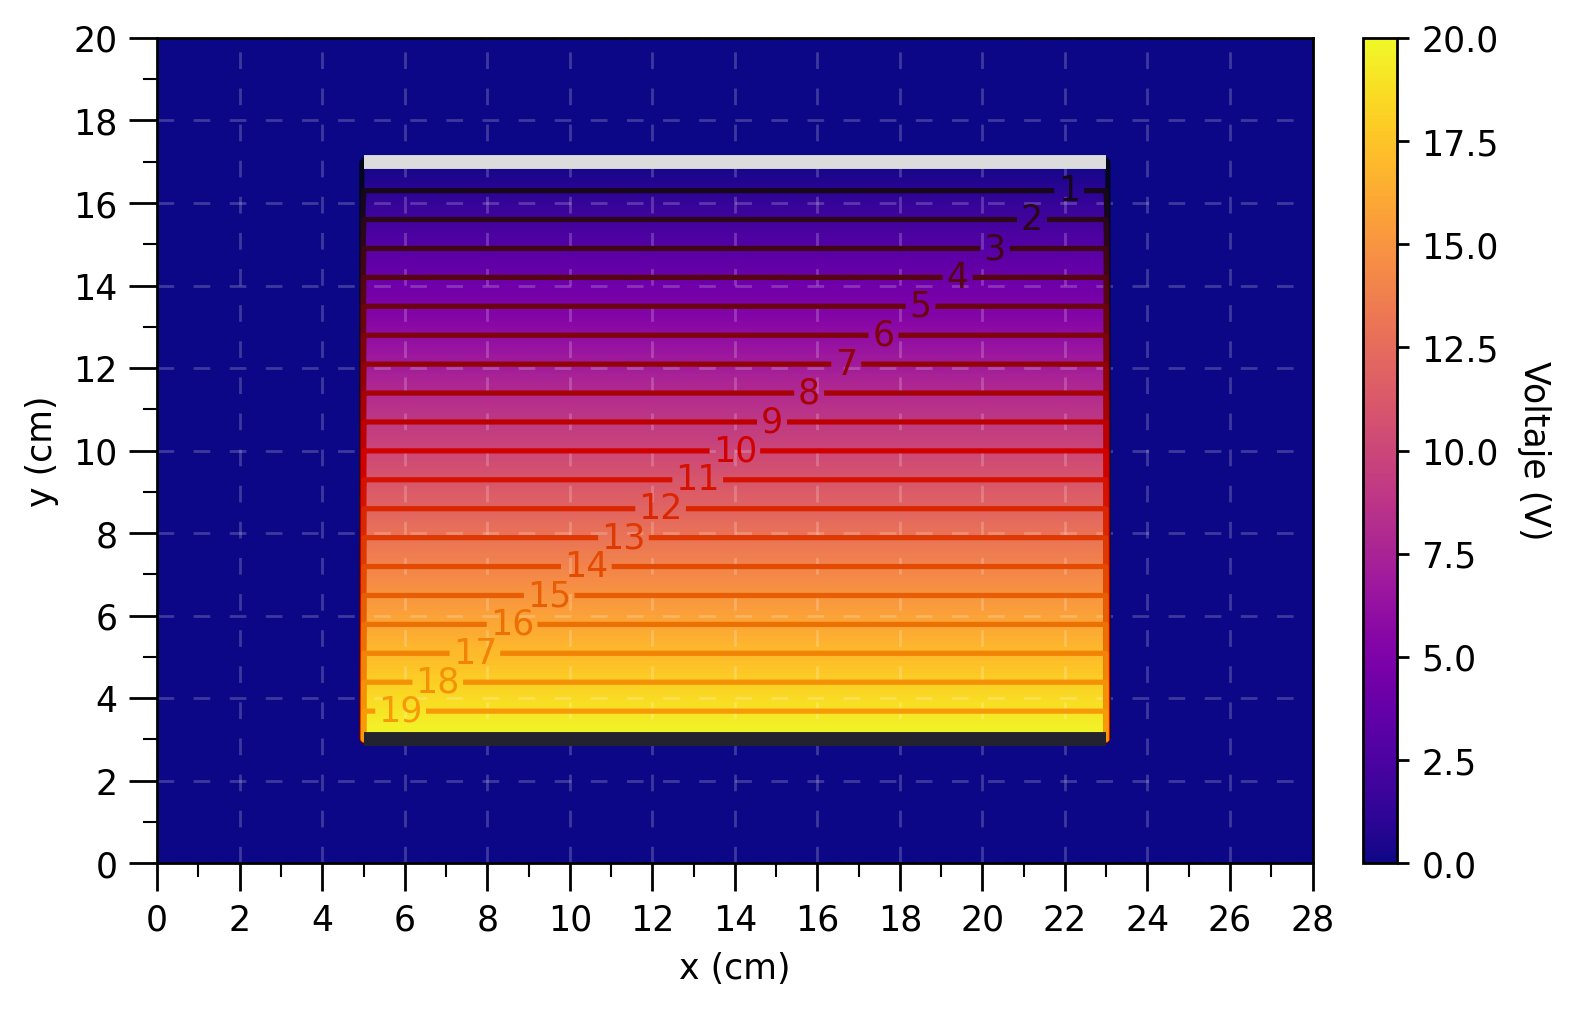

In [448]:
fig, ax = plt.subplots(dpi = 250)

divider = make_axes_locatable(ax)


levels = np.linspace(0,20,21)

norm = mcolors.Normalize(vmin = -0, vmax = 20)


img = ax.imshow(data, aspect='equal', cmap = "plasma", origin = "lower", interpolation = "nearest", extent = (0,28,0,20), norm = norm)

labelledLevels = levels[1:-1]
manual_locations = np.linspace((5, 3), (23, 17), len(levels))
labelledManualLocations = manual_locations[1:-1]

CS = ax.contour(X, Y, data, levels = levels, cmap = red_orange_cmap, zorder = 2, norm = norm)
ax.clabel(CS, fontsize = 10, manual = labelledManualLocations)


ax.hlines(17, 5, 23 , "gainsboro", lw = 4, zorder = 100)
ax.hlines(3, 5, 23, "#232330", lw = 4, zorder = 100)


cax = divider.append_axes("right", size="3%", pad=0.2)
cbar = fig.colorbar(img, cax=cax, norm = norm)
cbar.set_label('Voltaje (V)',rotation=-90,  labelpad=15)



ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#FFFFFF", zorder = 1, alpha = 0.2, ls = (0,(6,7)))

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")


plt.savefig("casoDosEquipotencialesTeoricasCondensador.png", dpi = 250, bbox_inches='tight', pad_inches=0.03)
plt.show()

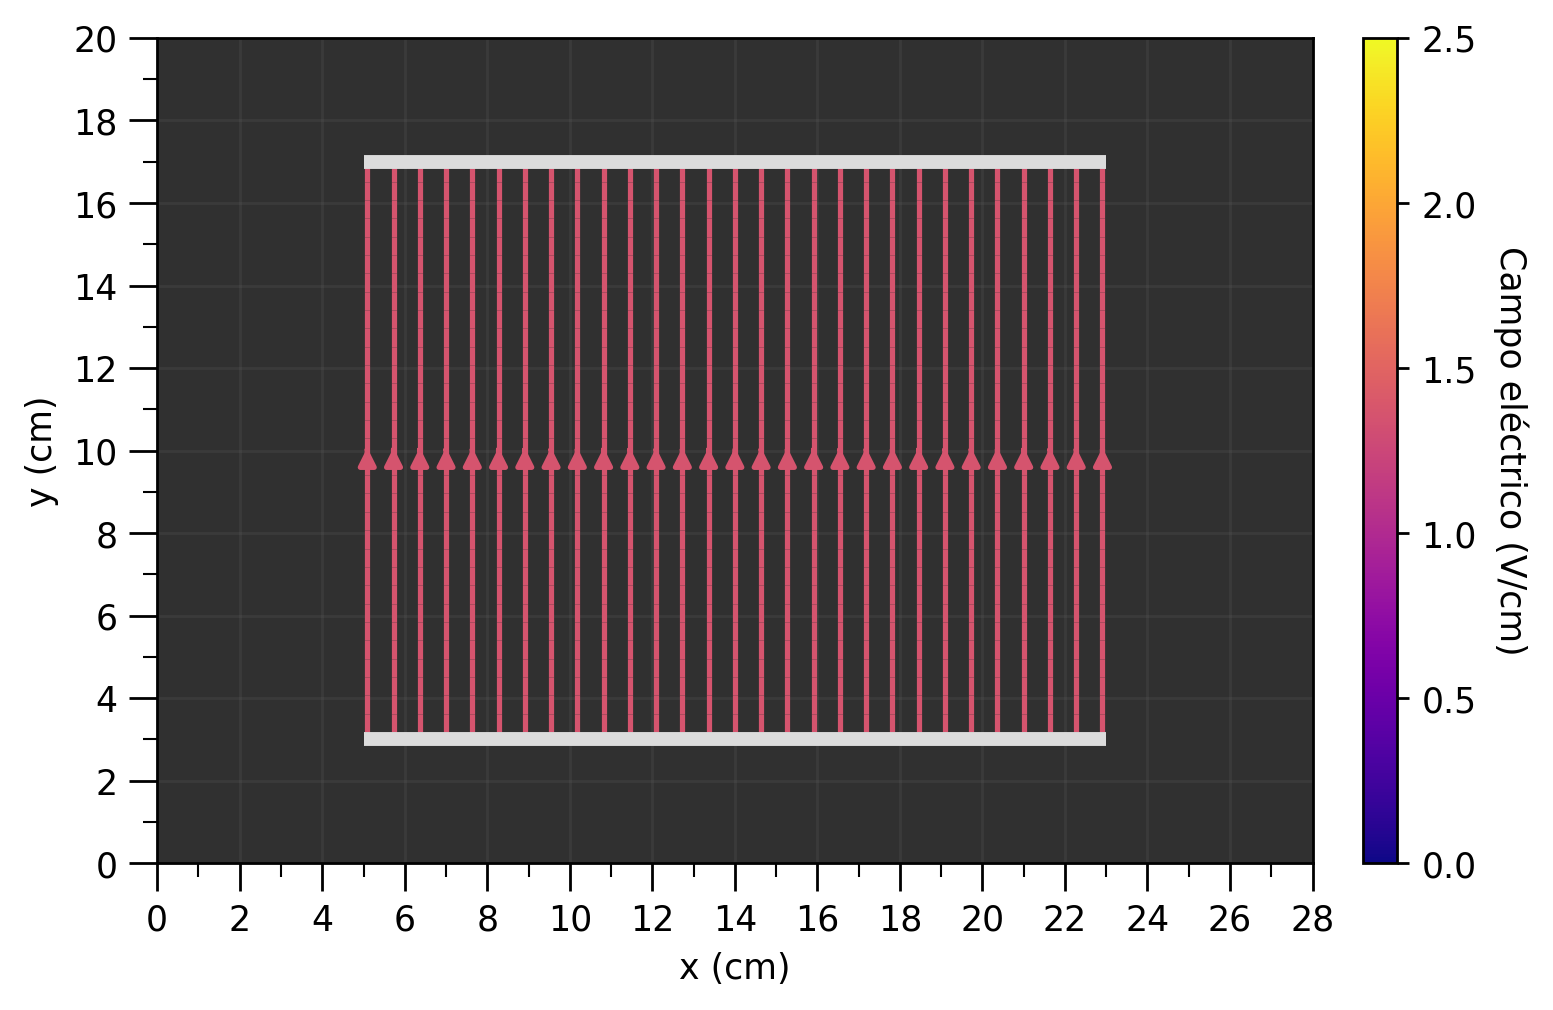

In [450]:
fig, ax = plt.subplots(dpi =250 )

divider = make_axes_locatable(ax)

skip = (slice(None, None, 20), slice(None, None, 20))
#ax.quiver(Y[skip],X[skip], normalizedFieldGradientV[skip], normalizedFieldGradientU[skip], fieldGradient[1][skip]*fieldGradient[0][skip], angles='xy', scale_units='xy', scale = 1, cmap = 'rainbow', pivot = "mid")

norm = mcolors.Normalize(vmin=0, vmax=2.5)

isStreamlineBroken = True
stream = plt.streamplot(X,Y,fieldGradient[1], fieldGradient[0],
                color = np.sqrt(fieldGradient[1]**2+fieldGradient[0]**2),
                density = 1.5, cmap = "plasma",
                broken_streamlines=isStreamlineBroken,
                        norm = norm)

ax.hlines(17, 5, 23 , "gainsboro", lw = 4, zorder = 11)
ax.hlines(3, 5, 23, "gainsboro", lw = 4, zorder = 11)

cax = divider.append_axes("right", size="3%", pad=0.2)
cbar = fig.colorbar(stream.lines, cax=cax)
cbar.set_label('Campo eléctrico (V/cm)',rotation=-90,  labelpad=15)

ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#666666", zorder = 10, alpha = 0.2, ls = "solid")

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")

ax.set_aspect("equal")

ax.set_facecolor('#303030')

plt.savefig(f"casoDosCampoElectricoTeoricoCondensador{isStreamlineBroken}.png", dpi = 250, bbox_inches='tight', pad_inches=0.03)
plt.show()

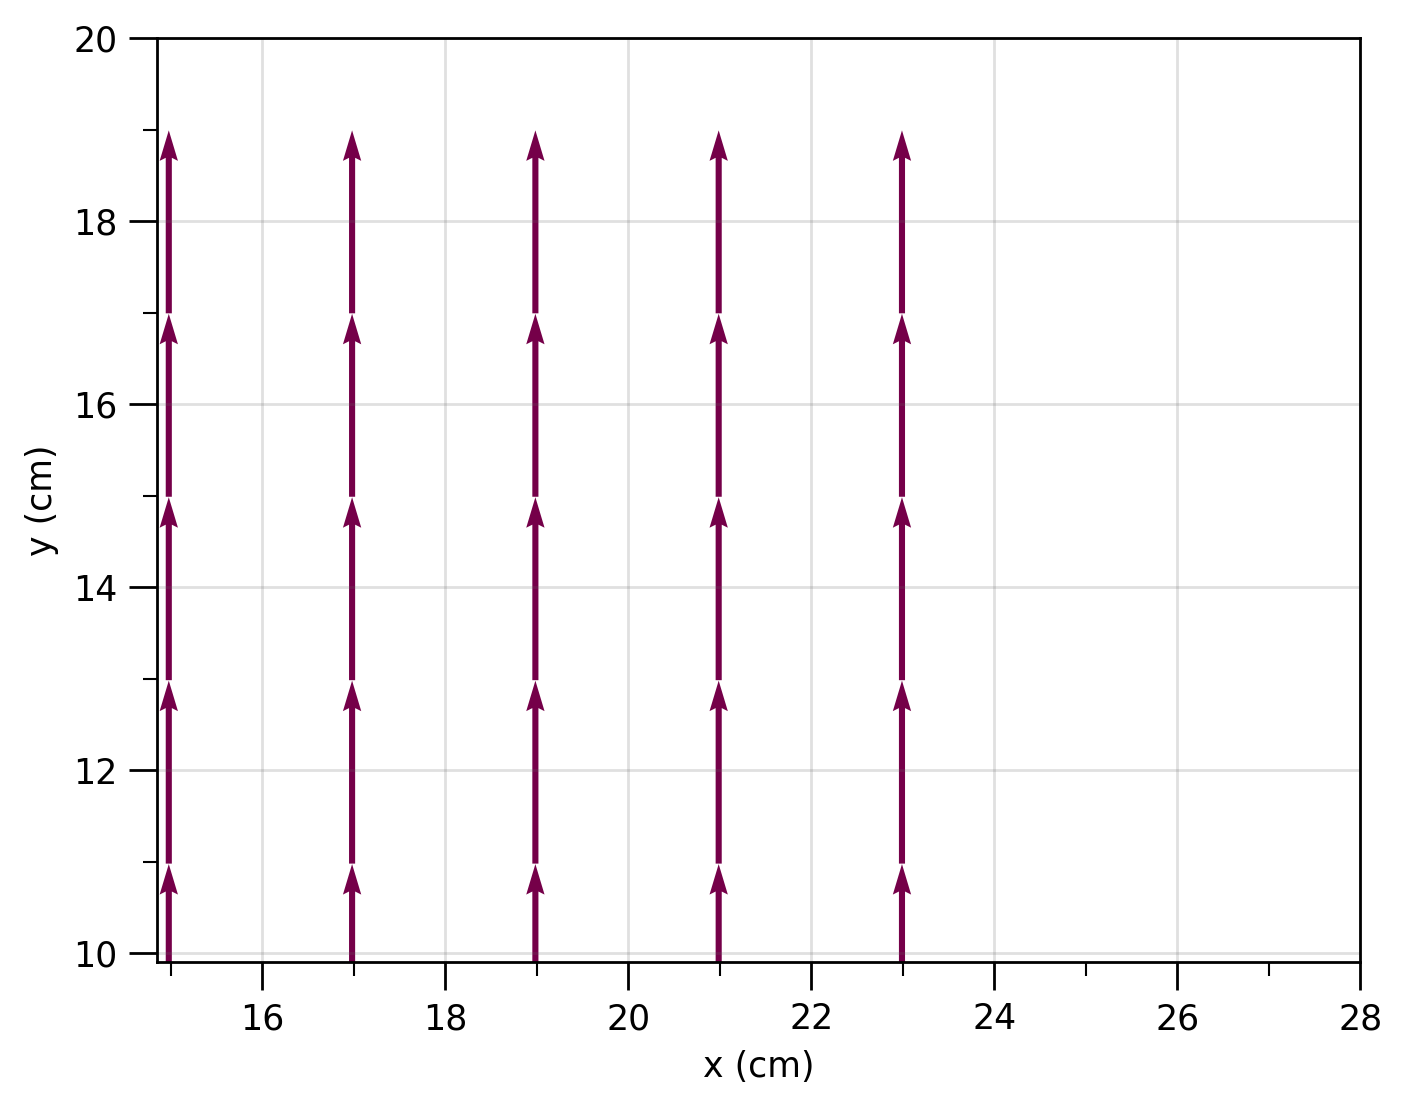

In [475]:
fig, ax = plt.subplots(dpi = 250)

skip = (slice(19, None, 40), slice(19, None, 40))
ax.quiver(X[skip],Y[skip], 2*normalizedFieldGradientV[skip], 2*normalizedFieldGradientU[skip], color = "#750049", angles='xy', scale_units='xy', scale = 1, cmap = 'rainbow')#, pivot = "mid")

ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#666666", zorder = 10, alpha = 0.2, ls = "solid")

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")

ax.set_aspect("equal")

#ax.set_facecolor('#303030')

ax.set_xlim(15*0.99,28)
ax.set_ylim(10*0.99,20)

plt.savefig(f"casoDosCampoElectricoTeoricoGridCondensador.png", dpi = 250, bbox_inches='tight', pad_inches=0.03)
plt.show()